# Mini-project: Advanced Statistical Analysis of Apple Inc. Stock Data

This notebook analyzes historical Apple Inc. stock prices using Pandas, NumPy, SciPy, and Matplotlib. The project covers data exploration, visualization, summary statistics, hypothesis testing, and bonus advanced statistical techniques.

## 1. Data Loading and Exploration

The first step is to load the dataset, inspect its structure, check for missing values, and understand the time-series properties of the data.

In [28]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import stats, signal

try:
    plt.style.use("seaborn-v0_8")
except OSError:
    plt.style.use("seaborn")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

path_candidates = [
    Path("apple_stock_prices.csv"),
    Path("week3/Day3/apple_stock_prices.csv"),
]
DATA_PATH = next((path for path in path_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find apple_stock_prices.csv. Put it beside this notebook or run Jupyter from the DI_Bootcamp folder.")

df = pd.read_csv(DATA_PATH)

# Standardize column names while preserving financial meaning.
df.columns = [str(col).strip().replace(" ", "_").replace(".", "").lower() for col in df.columns]
rename_map = {
    "adj_close": "adj_close",
    "adjclose": "adj_close",
    "adjusted_close": "adj_close",
    "date": "date",
    "open": "open",
    "high": "high",
    "low": "low",
    "close": "close",
    "volume": "volume"
}
df = df.rename(columns={col: rename_map.get(col, col) for col in df.columns})

required_cols = ["date", "open", "high", "low", "close", "volume"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}. Available columns: {df.columns.tolist()}")

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").set_index("date")

numeric_cols = ["open", "high", "low", "close", "adj_close", "volume"]
numeric_cols = [col for col in numeric_cols if col in df.columns]
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=["open", "high", "low", "close", "volume"])

df.head()

,open,high,low,close,adj_close,volume
date,,,,,,
1981-01-04,0.108817,0.108817,0.108259,0.108259,0.084242,34070400
1981-01-05,0.126674,0.127790,0.126674,0.126674,0.098571,16553600
1981-01-06,0.147879,0.148438,0.147879,0.147879,0.115072,51251200
1981-01-07,0.115513,0.115513,0.114955,0.114955,0.089452,170464000
1981-01-09,0.095424,0.095982,0.095424,0.095424,0.074254,37027200


In [18]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nDate range:", df.index.min().date(), "to", df.index.max().date())
print("Estimated frequency:", pd.infer_freq(df.index[:20]))
print("Median gap between observations:", df.index.to_series().diff().median())

Dataset shape: (4186, 6)

Data types:
open         float64
high         float64
low          float64
close        float64
adj_close    float64
volume         int64
dtype: object

Missing values:
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

Date range: 1981-01-04 to 2023-12-01
Estimated frequency: None
Median gap between observations: 1 days 00:00:00


**Exploration findings:**

- The dataset is a time series indexed by trading date.
- Stock market data is not truly daily calendar data because weekends and market holidays are absent.
- The main variables are price columns (`open`, `high`, `low`, `close`, `adj_close`) and trading `volume`.
- The adjusted close is especially useful for long-run analysis because it accounts for corporate actions such as stock splits.

## 2. Data Visualization

The following charts show the evolution of closing prices, trading volume, and high-low-open-close behavior over time.

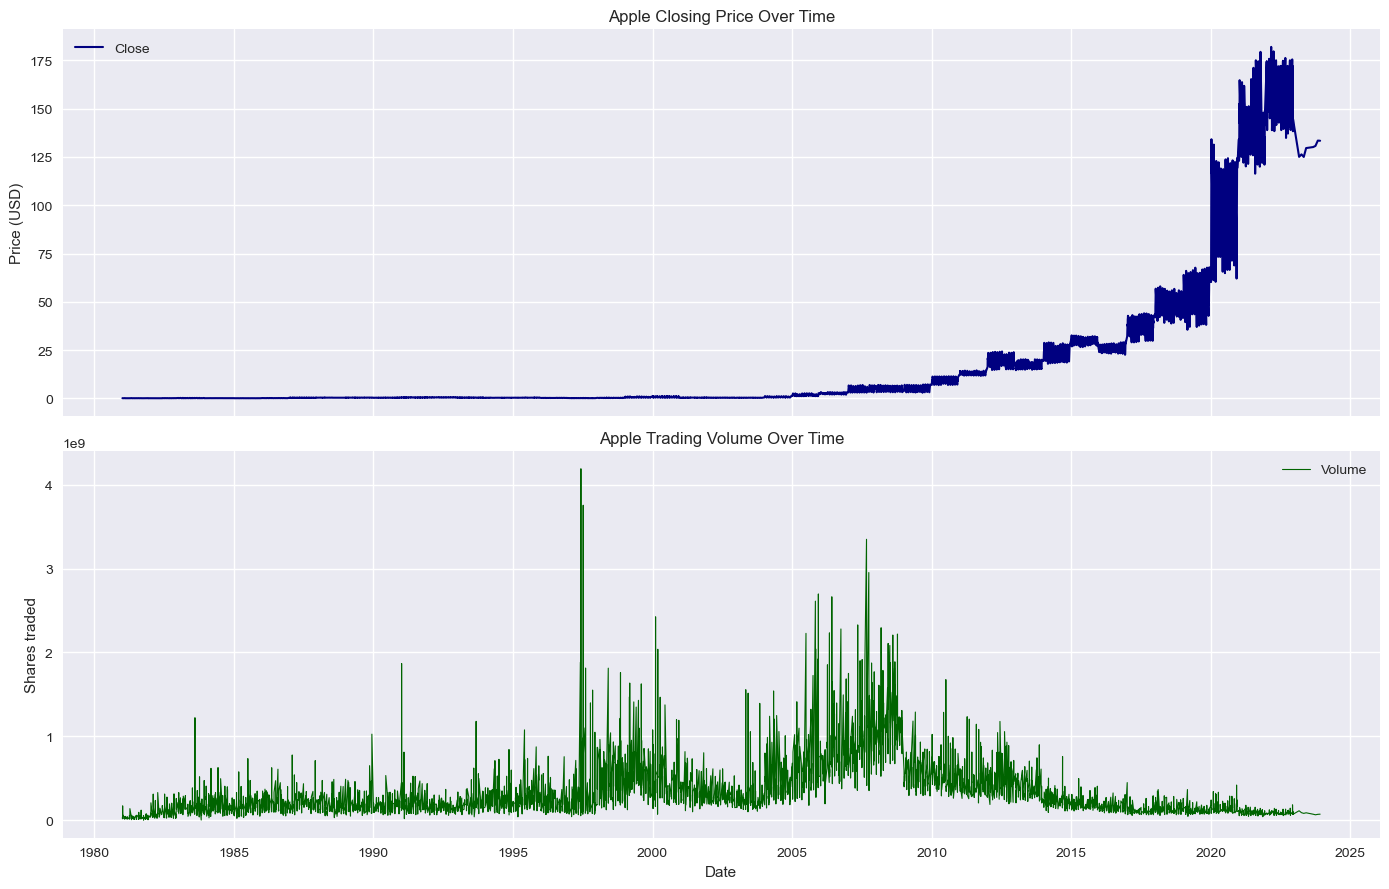

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df.index, df["close"], color="navy", linewidth=1.5, label="Close")
axes[0].set_title("Apple Closing Price Over Time")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

axes[1].plot(df.index, df["volume"], color="darkgreen", linewidth=0.8, label="Volume")
axes[1].set_title("Apple Trading Volume Over Time")
axes[1].set_ylabel("Shares traded")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

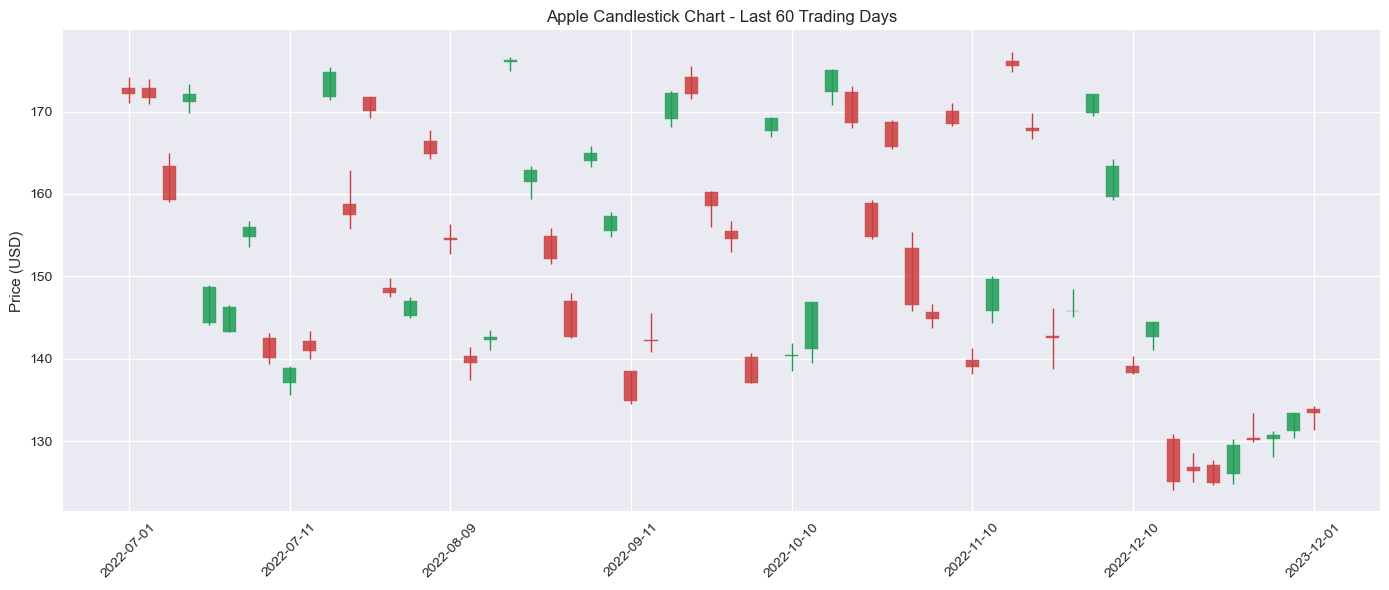

In [20]:
def plot_candlestick(data, title="Candlestick Chart"):
    """Draw a simple candlestick chart with Matplotlib only."""
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(data))
    width = 0.65

    for i, (_, row) in enumerate(data.iterrows()):
        color = "#1f9d55" if row["close"] >= row["open"] else "#cc3d3d"
        ax.vlines(i, row["low"], row["high"], color=color, linewidth=1)
        body_bottom = min(row["open"], row["close"])
        body_height = abs(row["close"] - row["open"])
        if body_height == 0:
            body_height = 0.01
        ax.add_patch(Rectangle((i - width / 2, body_bottom), width, body_height, color=color, alpha=0.85))

    tick_positions = np.linspace(0, len(data) - 1, min(8, len(data))).astype(int)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([data.index[i].strftime("%Y-%m-%d") for i in tick_positions], rotation=45)
    ax.set_title(title)
    ax.set_ylabel("Price (USD)")
    plt.tight_layout()
    plt.show()

# A recent subset keeps the candlesticks readable.
recent = df.tail(60)
plot_candlestick(recent, "Apple Candlestick Chart - Last 60 Trading Days")

**Visualization findings:**

- Closing prices show long-term growth with periods of sharp acceleration and correction.
- Volume spikes often appear around periods of market stress, major news, earnings, or split-related activity.
- The candlestick chart makes short-term volatility clearer by showing the daily trading range and whether price closed above or below the open.

## 3. Statistical Analysis

This section computes summary statistics and analyzes closing prices using moving averages.

In [21]:
summary_stats = df[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T
summary_stats

,mean,median,std,min,max
open,1.669548e+01,4.888390e-01,3.550979e+01,0.049665,1.826300e+02
high,1.688257e+01,4.963615e-01,3.592351e+01,0.049665,1.829400e+02
low,1.650129e+01,4.821430e-01,3.507802e+01,0.049107,1.791200e+02
close,1.669867e+01,4.888390e-01,3.550797e+01,0.049107,1.820100e+02
adj_close,1.602736e+01,4.057535e-01,3.518774e+01,0.038213,1.809597e+02
volume,3.267486e+08,2.146116e+08,3.338102e+08,0.000000,4.190480e+09


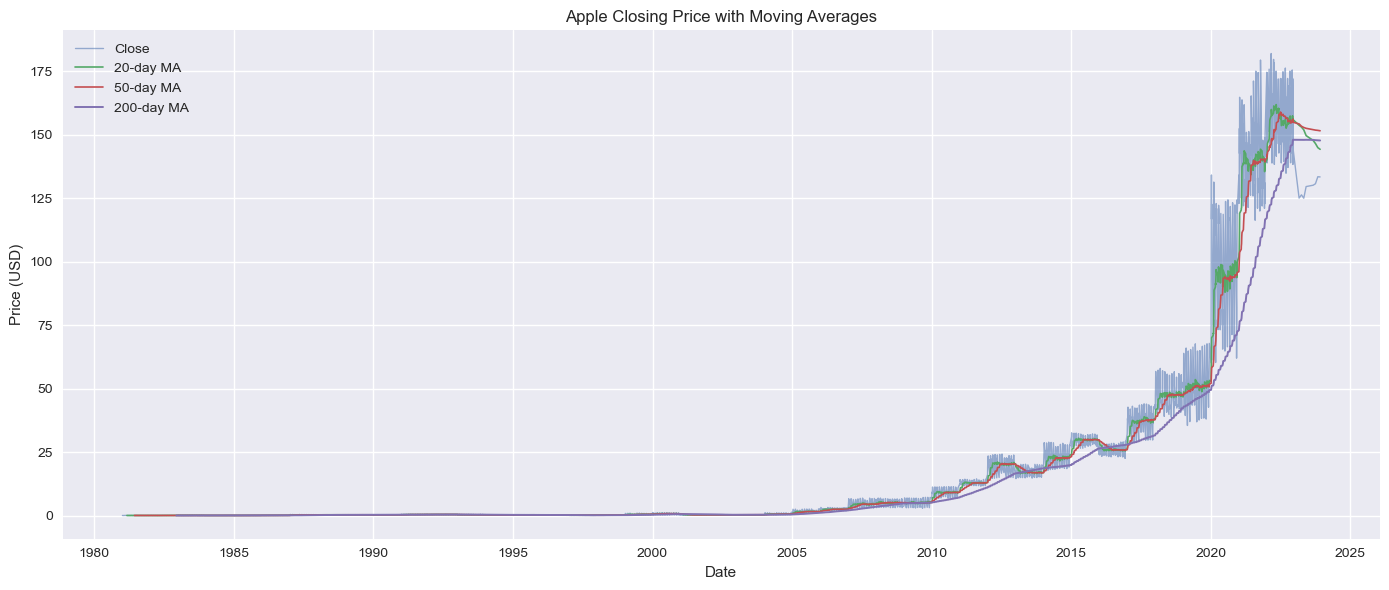

In [22]:
df["ma_20"] = df["close"].rolling(window=20).mean()
df["ma_50"] = df["close"].rolling(window=50).mean()
df["ma_200"] = df["close"].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["close"], label="Close", alpha=0.55, linewidth=1)
plt.plot(df.index, df["ma_20"], label="20-day MA", linewidth=1.2)
plt.plot(df.index, df["ma_50"], label="50-day MA", linewidth=1.2)
plt.plot(df.index, df["ma_200"], label="200-day MA", linewidth=1.4)
plt.title("Apple Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

**Statistical findings:**

- The mean and median summarize the central tendency of each financial metric, while the standard deviation measures dispersion.
- Moving averages smooth short-term noise and make trend direction easier to see.
- The 20-day moving average reacts quickly to price changes, while the 200-day moving average highlights the long-term trend.

## 4. Hypothesis Testing

This section compares average closing prices across years and tests whether daily returns follow a normal distribution.

In [23]:
df["year"] = df.index.year
years = sorted(df["year"].dropna().unique())
year_a, year_b = years[-2], years[-1]

close_a = df.loc[df["year"] == year_a, "close"].dropna()
close_b = df.loc[df["year"] == year_b, "close"].dropna()

t_stat, p_value = stats.ttest_ind(close_a, close_b, equal_var=False)

print(f"Comparing average closing prices: {year_a} vs {year_b}")
print(f"{year_a} mean close: {close_a.mean():.4f}")
print(f"{year_b} mean close: {close_b.mean():.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis. The average closing prices differ significantly.")
else:
    print("Result: Fail to reject the null hypothesis. No significant difference was detected.")

Comparing average closing prices: 2022 vs 2023
2022 mean close: 156.9366
2023 mean close: 129.2312
t-statistic: 15.6675
p-value: 0.000000
Result: Reject the null hypothesis. The average closing prices differ significantly.


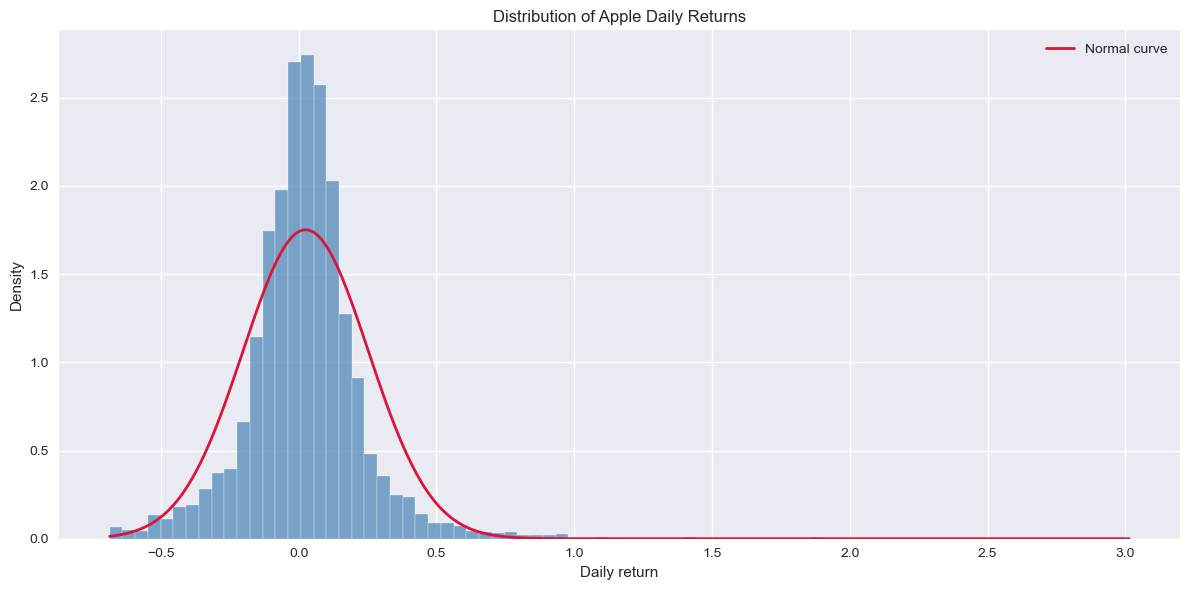

Daily return mean: 0.025303
Daily return standard deviation: 0.227792
Skewness: 2.3036
Kurtosis: 22.2645
D'Agostino normality test p-value: 0.00000000
Shapiro-Wilk test p-value on sample: 0.00000000
Result: Reject normality. Apple daily returns are not normally distributed.


In [24]:
alpha = 0.05

df["daily_return"] = df["close"].pct_change()
returns = df["daily_return"].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(12, 6))
plt.hist(returns, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="white")
x = np.linspace(returns.min(), returns.max(), 400)
normal_pdf = stats.norm.pdf(x, returns.mean(), returns.std(ddof=1))
plt.plot(x, normal_pdf, color="crimson", linewidth=2, label="Normal curve")
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

normaltest_stat, normaltest_p = stats.normaltest(returns)
shapiro_sample = returns.sample(n=min(5000, len(returns)), random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

print(f"Daily return mean: {returns.mean():.6f}")
print(f"Daily return standard deviation: {returns.std(ddof=1):.6f}")
print(f"Skewness: {stats.skew(returns):.4f}")
print(f"Kurtosis: {stats.kurtosis(returns):.4f}")
print(f"D'Agostino normality test p-value: {normaltest_p:.8f}")
print(f"Shapiro-Wilk test p-value on sample: {shapiro_p:.8f}")

if normaltest_p < alpha:
    print("Result: Reject normality. Apple daily returns are not normally distributed.")
else:
    print("Result: Fail to reject normality based on this test.")

**Hypothesis testing findings:**

- The two-sample t-test checks whether two years have meaningfully different average closing prices.
- The normality tests examine whether daily returns follow a normal distribution.
- Financial returns often show heavy tails and volatility clustering, so normality is commonly rejected for real stock data.

## 5. Advanced Statistical Techniques (Bonus)

This section applies SciPy signal processing and NumPy statistical functions to extract deeper insights.

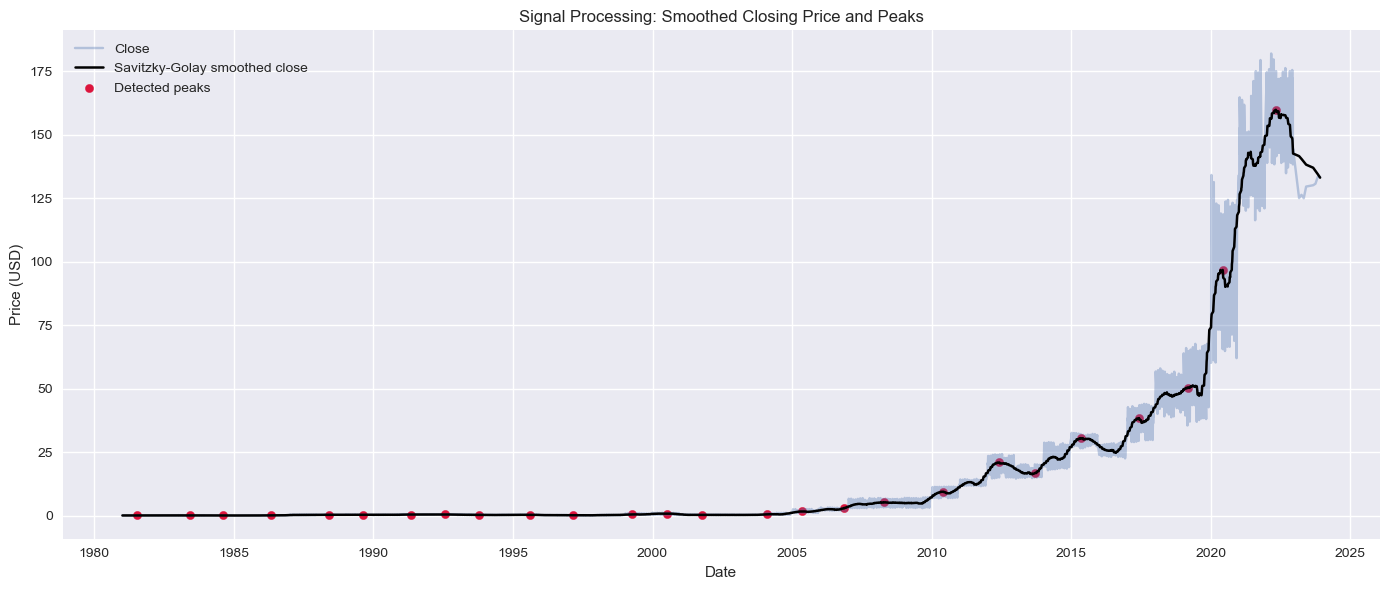

Detected 26 major smoothed-price peaks using SciPy find_peaks.


In [25]:
# Signal processing using SciPy: smooth the close price and identify local peaks.
window = 101 if len(df) >= 101 else max(5, len(df) // 2 * 2 + 1)
if window % 2 == 0:
    window += 1

df["savgol_close"] = signal.savgol_filter(df["close"].ffill(), window_length=window, polyorder=3)
peak_indices, peak_props = signal.find_peaks(df["savgol_close"], distance=120)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["close"], alpha=0.35, label="Close")
plt.plot(df.index, df["savgol_close"], color="black", linewidth=1.8, label="Savitzky-Golay smoothed close")
plt.scatter(df.index[peak_indices], df["savgol_close"].iloc[peak_indices], color="crimson", s=35, label="Detected peaks")
plt.title("Signal Processing: Smoothed Closing Price and Peaks")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Detected {len(peak_indices)} major smoothed-price peaks using SciPy find_peaks.")

Correlation between 30-day close MA and 30-day volume MA: -0.2913
Correlation between 30-day and 90-day close moving averages: 0.9961
NumPy close mean: 16.6987
NumPy close median: 0.4888
NumPy close standard deviation: 35.5080


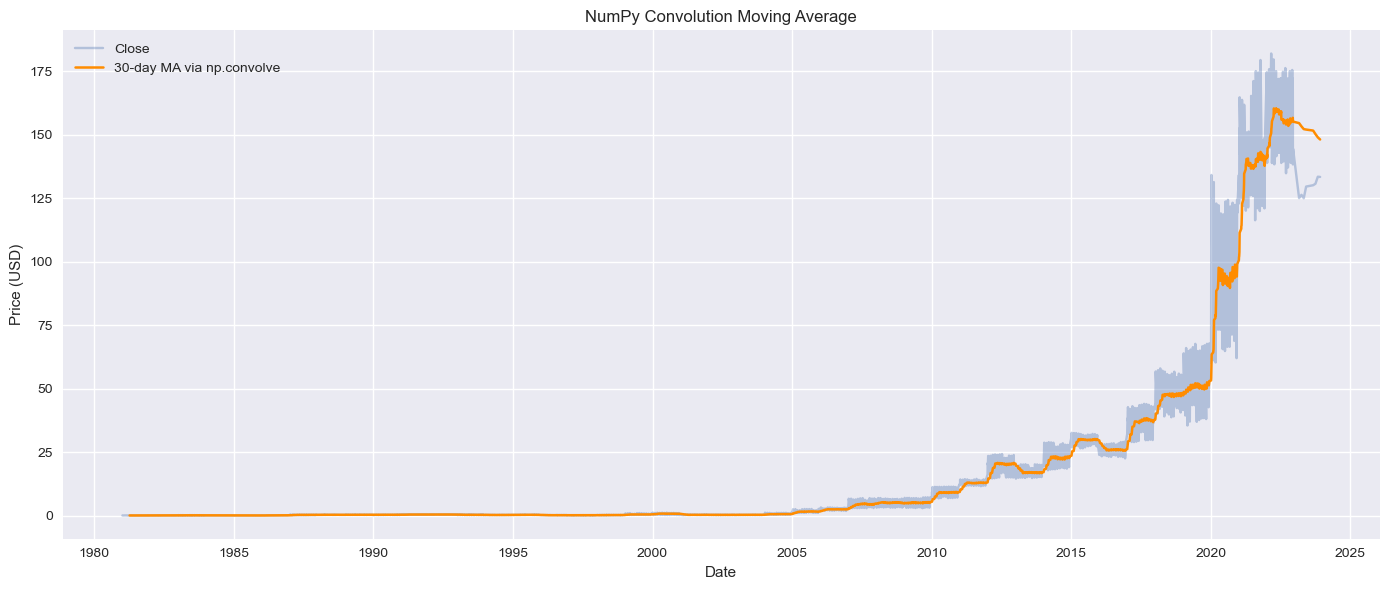

In [26]:
# Statistical functions in NumPy: moving average with convolution and correlations.
close_values = df["close"].ffill().to_numpy()
volume_values = df["volume"].ffill().to_numpy()

kernel_30 = np.ones(30) / 30
conv_ma_30 = np.convolve(close_values, kernel_30, mode="valid")
conv_dates = df.index[29:]

df["volume_ma_30"] = df["volume"].rolling(30).mean()
df["close_ma_30"] = df["close"].rolling(30).mean()
df["close_ma_90"] = df["close"].rolling(90).mean()

corr_close_volume = np.corrcoef(df[["close_ma_30", "volume_ma_30"]].dropna().T)[0, 1]
corr_ma_30_90 = np.corrcoef(df[["close_ma_30", "close_ma_90"]].dropna().T)[0, 1]

print(f"Correlation between 30-day close MA and 30-day volume MA: {corr_close_volume:.4f}")
print(f"Correlation between 30-day and 90-day close moving averages: {corr_ma_30_90:.4f}")
print(f"NumPy close mean: {np.mean(close_values):.4f}")
print(f"NumPy close median: {np.median(close_values):.4f}")
print(f"NumPy close standard deviation: {np.std(close_values, ddof=1):.4f}")

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["close"], alpha=0.35, label="Close")
plt.plot(conv_dates, conv_ma_30, color="darkorange", linewidth=1.8, label="30-day MA via np.convolve")
plt.title("NumPy Convolution Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

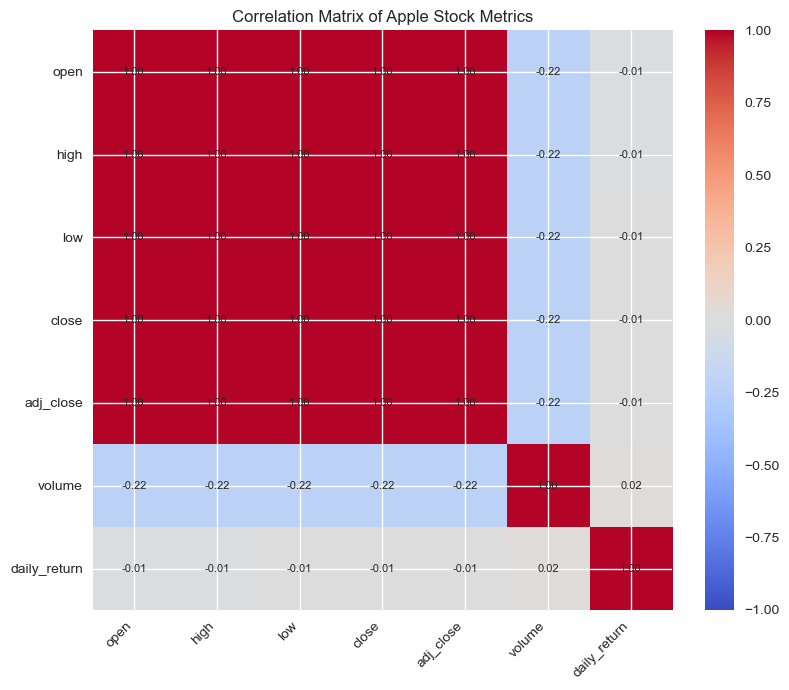

,open,high,low,close,adj_close,volume,daily_return
open,1.000000,0.999948,0.999915,0.999846,0.999567,-0.220109,-0.007889
high,0.999948,1.000000,0.999909,0.999918,0.999659,-0.219638,-0.007814
low,0.999915,0.999909,1.000000,0.999933,0.999636,-0.221026,-0.007549
close,0.999846,0.999918,0.999933,1.000000,0.999718,-0.220434,-0.007425
adj_close,0.999567,0.999659,0.999636,0.999718,1.000000,-0.222580,-0.007305
volume,-0.220109,-0.219638,-0.221026,-0.220434,-0.222580,1.000000,0.022597
daily_return,-0.007889,-0.007814,-0.007549,-0.007425,-0.007305,0.022597,1.000000


In [27]:
corr_data = df[["open", "high", "low", "close", "adj_close", "volume", "daily_return"]].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Apple Stock Metrics")

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

corr_matrix

**Advanced analysis findings:**

- `np.convolve` provides a fast way to compute moving averages using a fixed-size averaging kernel.
- `np.corrcoef` and Pandas correlation matrices show that price variables are highly correlated with each other because they measure related daily price levels.
- Volume usually has a weaker relationship with price level than price columns have with one another.
- SciPy signal processing can smooth noisy price data and identify major local peaks, but parameters such as window length and peak distance should be tuned carefully.

## 6. Summary and Insights

This analysis shows that Apple stock has experienced substantial long-term price growth, while also passing through periods of elevated volatility. Moving averages make the long-term trend easier to interpret and help separate persistent direction from short-term market noise.

The hypothesis test comparing the two most recent years evaluates whether average closing prices changed significantly. The exact conclusion depends on the computed p-value, but the test provides a formal statistical framework instead of relying only on visual comparison.

The daily returns analysis is especially important for financial data. Even when prices trend upward over long periods, daily percentage returns can be volatile, skewed, and heavy-tailed. The normality tests help confirm whether a normal distribution is a reasonable model for daily returns. In many stock datasets, normality is rejected, which means risk analysis should be careful about extreme events.

The bonus techniques add another layer of interpretation. NumPy convolution demonstrates efficient moving-average computation, correlations quantify relationships between metrics, and SciPy signal processing helps identify smoothed turning points in the price series.

## 7. Reflection

One challenge in this project was working with financial time-series data, which does not follow a simple calendar-day frequency because trading only happens on market days. This was handled by sorting the data by date and interpreting frequency carefully.

Another challenge was choosing statistical tests that produce meaningful insights. A t-test is useful for comparing average closing prices across years, but it does not explain every market factor behind the difference. For daily returns, normality testing is helpful because stock returns often violate the assumptions of a normal distribution.

A final challenge was selecting visualization methods that communicate both long-term trends and short-term behavior. Line charts worked well for closing price and volume, while the candlestick chart helped show daily high-low ranges and open-close direction. Moving averages and signal smoothing made the trend easier to interpret without removing the underlying financial context.